In [14]:
!pip install pennylane --quiet
!pip install pennylane-lightning[gpu] --quiet

In [15]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np
import math

In [16]:
num_qubits = 14
num_layers = 6
dev = qml.device("lightning.gpu", wires=num_qubits)

coeffs = []
observables = []
for i in range(num_qubits - 1):
    coeffs.append(-1.0)
    observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
for i in range(num_qubits):
    coeffs.append(-1.0)
    observables.append(qml.PauliX(i))
H = qml.Hamiltonian(coeffs, observables)

def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

# Note: Eigendecomposition on 10 qubits (1024x1024) might take a moment.
# eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
# delta = eigvals[1] - eigvals[0]

np.random.seed(42)
init_params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
grad_fn = qml.grad(cost_fn)


In [17]:
params_hybrid = init_params.copy()
hybrid_costs = []
prev_cost = np.inf
mode = "weinstein"
fixed_lr = 0.1

print("--- Starting Hybrid Run ---")
for step in range(50):
    cost = cost_fn(params_hybrid)
    hybrid_costs.append(cost)

    var = var_fn(params_hybrid)
    std = np.sqrt(var)
    grad = grad_fn(params_hybrid)
    grad_norm_sq = np.sum(grad**2)

    if mode == "weinstein" and cost > prev_cost:
        print(f"Step {step:03d}: Loss increased! Switching to standard SGD.")
        mode = "sgd"

    # elif mode in ["weinstein", "sgd"] and std < delta:
    #     print(f"Step {step:03d}: std < delta. Switching to Temple phase.")
    #     mode = "temple"

    print(f"Step {step:03d}: Cost = {cost:.6f} | Mode = {mode}")

    if mode == "weinstein":
        lr = std / (grad_norm_sq + 1e-8)
    elif mode == "temple":
        lr = (var / delta) / (grad_norm_sq + 1e-8)
    else:
        lr = fixed_lr

    params_hybrid = params_hybrid - lr * grad
    prev_cost = cost


--- Starting Hybrid Run ---
Step 000: Cost = -0.203811 | Mode = weinstein
Step 001: Cost = -1.804330 | Mode = weinstein
Step 002: Cost = -3.665741 | Mode = weinstein
Step 003: Cost = -4.599586 | Mode = weinstein
Step 004: Cost = -5.859609 | Mode = weinstein
Step 005: Cost = -6.005162 | Mode = weinstein
Step 006: Cost = -7.764174 | Mode = weinstein
Step 007: Loss increased! Switching to standard SGD.
Step 007: Cost = -6.681484 | Mode = sgd
Step 008: Cost = -8.120515 | Mode = sgd
Step 009: Cost = -9.148768 | Mode = sgd
Step 010: Cost = -9.747735 | Mode = sgd
Step 011: Cost = -10.096662 | Mode = sgd
Step 012: Cost = -10.351666 | Mode = sgd
Step 013: Cost = -10.582002 | Mode = sgd
Step 014: Cost = -10.809523 | Mode = sgd
Step 015: Cost = -11.038593 | Mode = sgd
Step 016: Cost = -11.267536 | Mode = sgd
Step 017: Cost = -11.492524 | Mode = sgd
Step 018: Cost = -11.709227 | Mode = sgd
Step 019: Cost = -11.913833 | Mode = sgd
Step 020: Cost = -12.103755 | Mode = sgd
Step 021: Cost = -12.277934

In [18]:

# --- 2. Pure SGD Run ---
params_sgd = init_params.copy()
sgd_costs = []

print("\n--- Starting Pure SGD Run ---")
for step in range(50):
    cost = cost_fn(params_sgd)
    sgd_costs.append(cost)
    grad = grad_fn(params_sgd)

    if step%10 == 0:
        print(f"Step {step:03d}: Cost = {cost:.6f}")
    params_sgd = params_sgd - fixed_lr * grad


--- Starting Pure SGD Run ---
Step 000: Cost = -0.203811
Step 010: Cost = -2.159008
Step 020: Cost = -4.533443
Step 030: Cost = -7.969767
Step 040: Cost = -11.824285


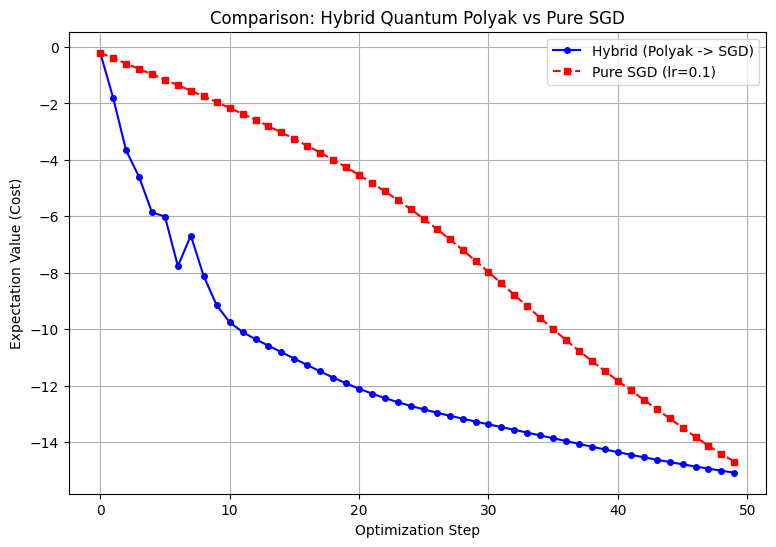

In [19]:
# --- 3. Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(hybrid_costs, marker='o', markersize=4, linestyle='-', color='b', label='Hybrid (Polyak -> SGD)')
plt.plot(sgd_costs, marker='s', markersize=4, linestyle='--', color='r', label=f'Pure SGD (lr={fixed_lr})')
plt.xlabel("Optimization Step")
plt.ylabel("Expectation Value (Cost)")
plt.title("Comparison: Hybrid Quantum Polyak vs Pure SGD")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from scipy import stats

params_hybrid = init_params.copy()
energies_ours = []
prev_cost = np.inf

vs_ours = []
running_energy_estimate = []
running_spec_gap_estimate = []

is_temple = False
w_size = 10
print("--- Starting W T Run ---")
for step in range(50):
    cost = cost_fn(params_hybrid)
    energies_ours.append(cost)

    var = var_fn(params_hybrid)
    vs_ours.append(var)
    std = np.sqrt(var)
    grad = grad_fn(params_hybrid)
    grad_norm_sq = np.sum(grad**2)


    if step > w_size+1:
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(vs_ours[-w_size:], energies_ours[-w_size:])
        running_energy_estimate.append(intercept)
        running_spec_gap_estimate.append(1/slope)
        # Calculate R-squared for goodness of fit
        r_squared = r_value**2

        if r_squared >= 0.7 and not is_temple:
            is_temple = True
            temple_step_when = step
            temple_step = 0.25 * slope

    else:
        running_energy_estimate.append(0)

    if step%10 == 0:
        print(f"Step {step:03d}: Cost = {cost:.6f} | Mode = {mode}")


    lr = std / (grad_norm_sq + 1e-8)
    if is_temple:
        lr = temple_step

    params_hybrid = params_hybrid - lr * grad
    prev_cost = cost

--- Starting W T Run ---
Step 000: Cost = -0.203811 | Mode = sgd
Step 010: Cost = -12.182530 | Mode = sgd
Step 020: Cost = -14.395770 | Mode = sgd
Step 030: Cost = -15.277203 | Mode = sgd
Step 040: Cost = -15.790765 | Mode = sgd


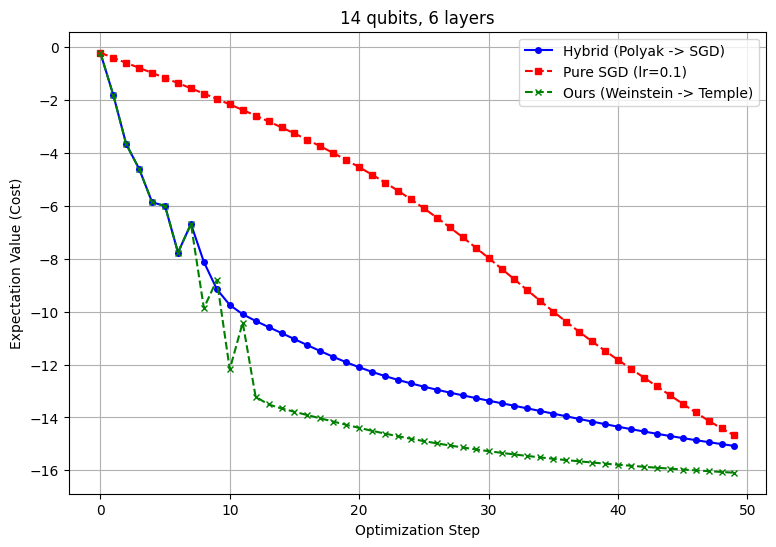

In [21]:
# --- 3. Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(hybrid_costs, marker='o', markersize=4, linestyle='-', color='b', label='Hybrid (Polyak -> SGD)')
plt.plot(sgd_costs, marker='s', markersize=4, linestyle='--', color='r', label=f'Pure SGD (lr={fixed_lr})')
plt.plot(energies_ours, marker='x', markersize=4, linestyle='--', color='g', label='Ours (Weinstein -> Temple)')

plt.xlabel("Optimization Step")
plt.ylabel("Expectation Value (Cost)")
plt.title(f"{num_qubits} qubits, {num_layers} layers")
plt.legend()
plt.grid(True)
plt.show()

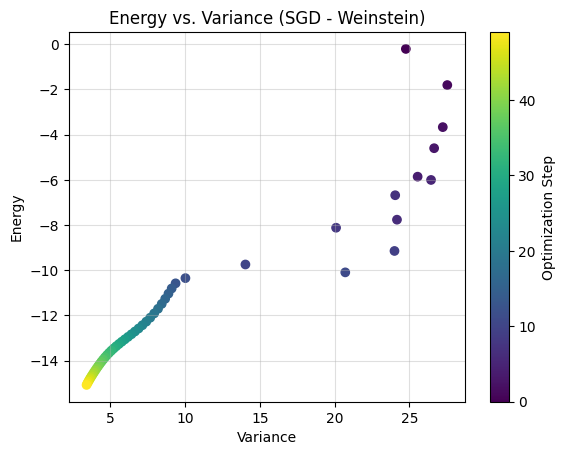

In [23]:
plt.scatter(x=vs_ours, y=hybrid_costs, c=np.arange(len(vs_ours)), cmap='viridis')
plt.xlabel("Variance")
plt.ylabel("Energy")
plt.title("Energy vs. Variance (SGD - Weinstein)")
plt.colorbar(label="Optimization Step") # Add a color bar to show the step progression
plt.grid(alpha=0.4)